<a href="https://colab.research.google.com/github/ikabrain/UCS761-Deep-Learning-Lab/blob/main/DL_assign5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 5 - Designing different activation functions
---

## Initialising
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## Base Classes
---

In [2]:
class Layer:
    """
    Base class for any layer in a neural network.
    """
    def forward(self, X):
        raise NotImplementedError

    def __call__(self, X):
        return self.forward(X)

    def backward(self, dA):
        # Here, dA is the activated gradient from the NEXT layer that has propagated to here for current output!
        raise NotImplementedError

    def _update(self, lr):
        # We update all the layers AFTER all the gradients have propagated through the network!
        pass # Left blank for activation layers which have no parameters

In [3]:
class Activation(Layer):
    """
    Base class for activation functions.
    """
    def derivative(self):
        raise NotImplementedError

    def plot(self, x_min=-10, x_max=10, x_step=1000, title="Activation Function", fn_label="f(x)", d_label="f'(x)"):
        # X-axis for graphs
        x = np.linspace(x_min, x_max, x_step)
        plt.plot(x, self.forward(x), label=fn_label)
        plt.plot(x, self.derivative(x), label=d_label)
        plt.title(title)
        plt.xlabel("x")
        plt.ylabel("y")
        plt.legend()
        plt.grid()

## Activation Functions
---

### 1. Binary Step Function (Threshold Function)

$$
    f(x) =
    \begin{cases}
        1 & \text{if } x \geq 0 \\
        0 & \text{if } x < 0
    \end{cases}
$$

$$
    \Rightarrow
    f'(x) =
    \begin{cases}
        0 & \text{for } x \neq 0 \\
        undefined & \text{for } x = 0
    \end{cases}
$$

In [4]:
class BinaryStep(Activation):
    def forward(self, X):
        self.X = X
        return (X >= 0).astype(np.float32)

    def derivative(self, X=None):
        if X is None:
            X = self.X
        # Approximating derivative at x = 0 to be 0
        return np.zeros_like(X, dtype=np.float32)

    def backward(self, dA):
        # Propagating zero matrix
        return np.zeroes_like(dA, dtype=np.float32)

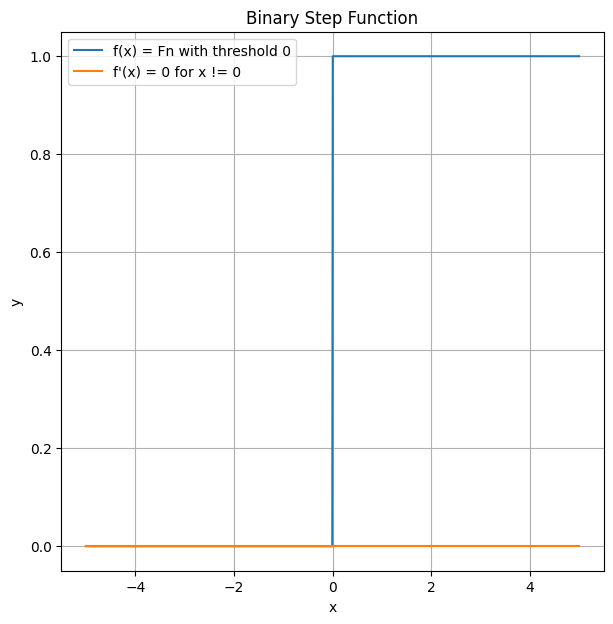

In [5]:
plt.figure(figsize=(7, 7))
thresh = BinaryStep()
thresh.plot(-5, 5, 1000, "Binary Step Function", "f(x) = Fn with threshold 0", "f'(x) = 0 for x != 0")
plt.show()

### 2. Linear Function

$$
    f(x) = x
$$

$$
    \Rightarrow
    f'(x) = 1
$$

In [6]:
class Linear(Activation):
    def forward(self, X):
        self.X = X
        return X.astype(np.float32)

    def derivative(self, X=None):
        if X is None:
            X = self.X
        return np.ones_like(X, dtype=np.float32)

    def backward(self, dA):
        return dA.astype(np.float32)

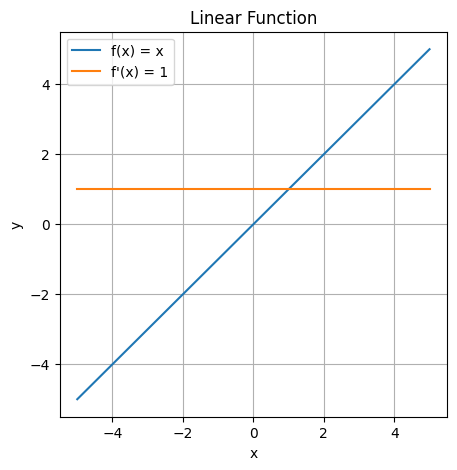

In [7]:
plt.figure(figsize=(5, 5))
lin = Linear()
lin.plot(-5, 5, 1000, "Linear Function", "f(x) = x", "f'(x) = 1")
plt.show()

### 3. Sigmoid Function

$$
    \sigma(x) = \frac{1}{1 + e^{-x}}
$$

$$
    \Rightarrow
    \sigma'(x) = \frac{e^{-x}}{( 1 + e^{-x})^2} = \sigma(x)\cdot(1 - \sigma(x))
$$

In [8]:
class Sigmoid(Activation):
    def forward(self, X):
        self.X = X
        X_clipped = np.clip(X, -500, 500) # For numerical stability
        return 1 / (1 + np.exp(-X_clipped))

    def derivative(self, X=None):
        if X is None:
            X = self.X
        X_clipped = np.clip(X, -500, 500)
        A = 1 / (1 + np.exp(-X_clipped))
        return (A * (1 - A)).astype(np.float32)

    def backward(self, dA):
        return dA * self.derivative()

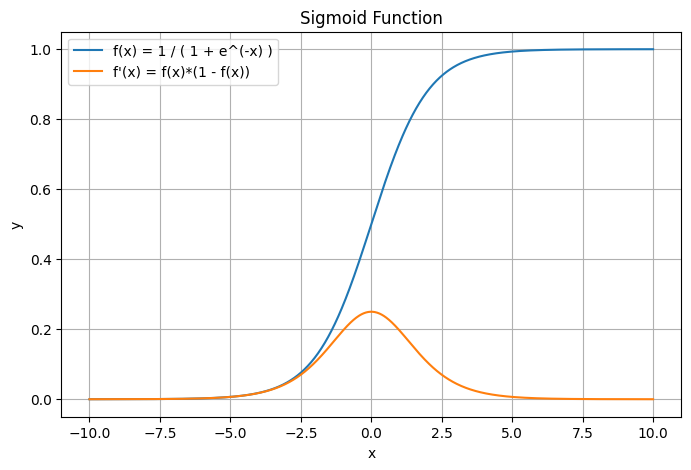

In [9]:
plt.figure(figsize=(8, 5))
sig = Sigmoid()
sig.plot(-10, 10, 1000, "Sigmoid Function", "f(x) = 1 / ( 1 + e^(-x) )", "f'(x) = f(x)*(1 - f(x))")
plt.show()

### 4. Tanh Function

$$
    tanh(x)
    = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}
    = \frac{1 - e^{-2x}}{1 + e^{-2x}}
    = \frac{2}{1 + e^{-2x}} - 1
$$

$$
    \Rightarrow
    tanh'(x) = sech^{2}(x) = 1 - tanh^{2}(x)
$$

In [10]:
class Tanh(Activation):
    def forward(self, X):
        self.X = X
        return np.tanh(X).astype(np.float32)

    def derivative(self, X=None):
        if X is None:
            X = self.X
        T = np.tanh(X)
        return (1 - T**2).astype(np.float32)

    def backward(self, dA):
        return dA * self.derivative()

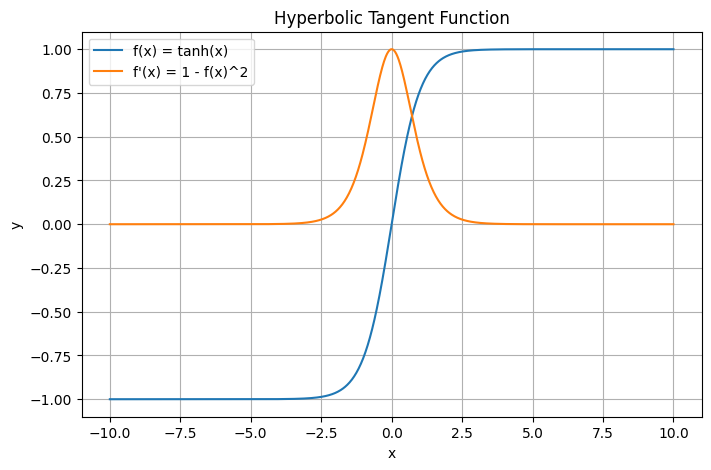

In [11]:
plt.figure(figsize=(8, 5))
tanh = Tanh()
tanh.plot(-10, 10, 1000, "Hyperbolic Tangent Function", "f(x) = tanh(x)", "f'(x) = 1 - f(x)^2")
plt.show()

### 5. Rectified Linear Unit (ReLU) Function

$$
    ReLU(x) = max\{0, x\} =
    \begin{cases}
        0 & \text{ for } x < 0 \\
        x & \text{ for } x \geq 0
    \end{cases}
$$

$$
    \Rightarrow
    ReLU'(x) =
    \begin{cases}
        0 & \text{ for } x < 0 \\
        1 & \text{ for } x \geq 0
    \end{cases}
$$

In [12]:
class ReLU(Activation):
    def forward(self, X):
        self.X = X
        return np.maximum(0, X).astype(np.float32)

    def derivative(self, X=None):
        if X is None:
            X = self.X
        return (X >= 0).astype(np.float32)

    def backward(self, dA):
        return dA * self.derivative()

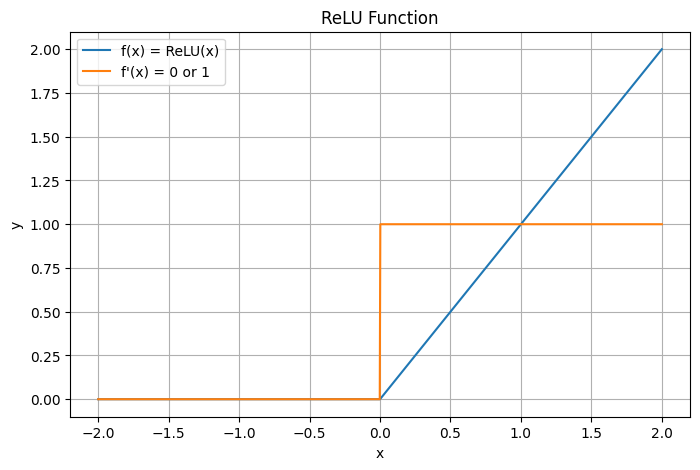

In [13]:
plt.figure(figsize=(8, 5))
relu = ReLU()
relu.plot(-2, 2, 1000, "ReLU Function", "f(x) = ReLU(x)", "f'(x) = 0 or 1")
plt.show()

### 6. Leaky ReLU Function

### 7. Parametric ReLU Function

### 8. Exponential Linear Unit (ELU) Function

### 9. Softmax Function

### 10. Swish (Self-Gated) Function

### 11. Gaussian Error Linear Unit (GELU) Function

### 12. Scaled Exponential Linear Unit (SELU) Function